In [1]:
# ── Cell 1: Load everything we need ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set a clean, professional plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'Arial',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Load the clean feature dataset
all_data = pd.read_csv('../data/processed/features_all_batteries.csv')

# Load both trained models
rf_soh      = joblib.load('../models/rf_soh_model.pkl')
rf_rul_norm = joblib.load('../models/rf_rul_norm_model.pkl')

# Define feature columns — must match exactly what the models were trained on
FEATURE_COLS = [
    'cycle_norm',
    'capacity_rolling_5',
    'capacity_delta',
    'capacity_accel',
    'temperature',
    'capacity_fade',
]

# Isolate the 4 core batteries for visualisation
core_batteries = ['B0005', 'B0006', 'B0007', 'B0018']
core_data = all_data[all_data['battery_id'].isin(core_batteries)].copy()

# Generate predictions for all core battery cycles
X_core = core_data[FEATURE_COLS]
core_data['SOH_predicted']      = rf_soh.predict(X_core)
core_data['RUL_norm_predicted'] = rf_rul_norm.predict(X_core)

print(f"Core battery data loaded: {core_data.shape}")
print(f"Batteries: {core_data['battery_id'].unique().tolist()}")
print(f"\nPrediction sample:")
print(core_data[['battery_id', 'test_id', 'SOH', 
                  'SOH_predicted', 'RUL_norm', 
                  'RUL_norm_predicted']].head(8).round(4).to_string())

Core battery data loaded: (636, 16)
Batteries: ['B0005', 'B0006', 'B0007', 'B0018']

Prediction sample:
  battery_id  test_id     SOH  SOH_predicted  RUL_norm  RUL_norm_predicted
0      B0005        1  1.0000         1.0000    1.0000              0.9992
1      B0005        3  0.9945         0.9944    0.9966              0.9905
2      B0005        5  0.9886         0.9884    0.9932              0.9909
3      B0005        7  0.9886         0.9884    0.9898              0.9916
4      B0005        9  0.9882         0.9877    0.9864              0.9959
5      B0005       11  0.9888         0.9886    0.9831              0.9900
6      B0005       13  0.9885         0.9884    0.9797              0.9935
7      B0005       15  0.9834         0.9830    0.9763              0.9829


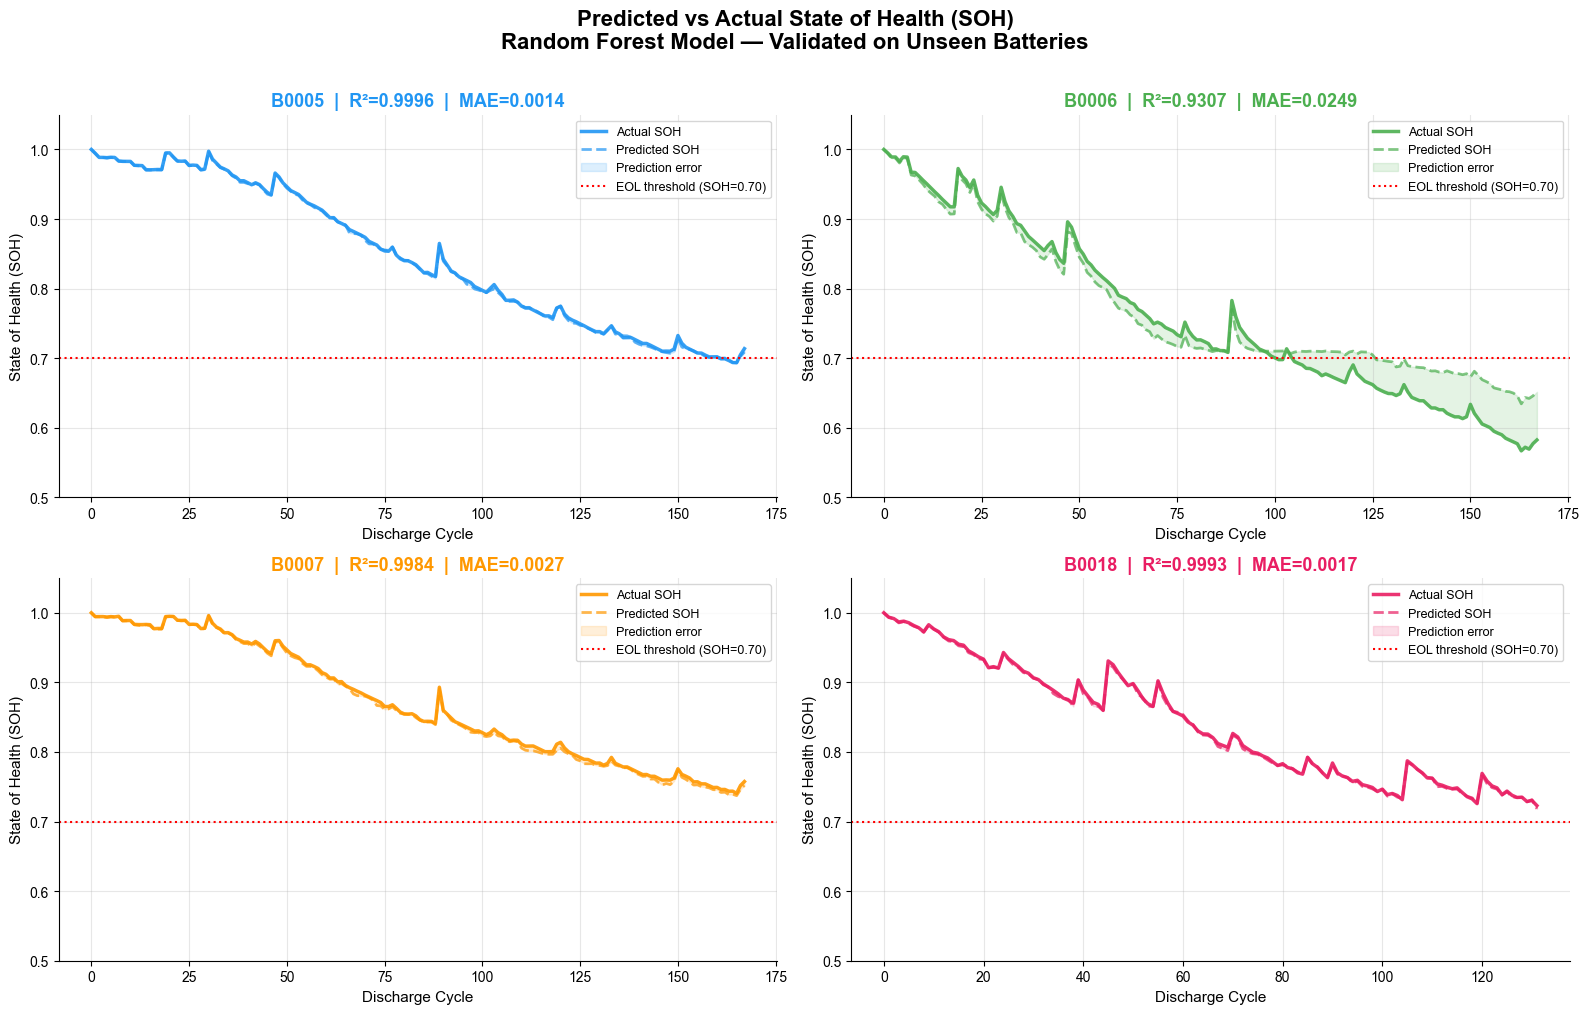

Figure 1 saved: ../figures/03_soh_predicted_vs_actual.png


In [2]:
# ── Cell 2: Figure 1 — Predicted vs Actual SOH for all 4 core batteries ───────
#
# This is your headline figure. Each subplot shows one battery's complete
# lifecycle — actual SOH in solid colour, predicted SOH as dashed line.
# The closer the dashed line follows the solid line, the better the model.
# A good result looks like the dashed line is almost indistinguishable
# from the solid line across the full degradation curve.

colors = {
    'B0005': '#2196F3',   # Blue
    'B0006': '#4CAF50',   # Green  
    'B0007': '#FF9800',   # Orange
    'B0018': '#E91E63',   # Pink
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, battery_id in enumerate(core_batteries):
    ax = axes[idx]
    battery = core_data[core_data['battery_id'] == battery_id].sort_values('test_id')
    
    cycles = range(len(battery))
    color  = colors[battery_id]
    
    # Actual SOH — solid line, full opacity
    ax.plot(cycles, battery['SOH'].values,
            color=color, linewidth=2.5, label='Actual SOH', alpha=0.9)
    
    # Predicted SOH — dashed line, slightly lighter
    ax.plot(cycles, battery['SOH_predicted'].values,
            color=color, linewidth=2, linestyle='--', 
            label='Predicted SOH', alpha=0.7)
    
    # Shade the area between actual and predicted to show error magnitude
    ax.fill_between(cycles,
                    battery['SOH'].values,
                    battery['SOH_predicted'].values,
                    alpha=0.15, color=color, label='Prediction error')
    
    # End-of-life threshold
    ax.axhline(y=0.70, color='red', linestyle=':', 
               linewidth=1.5, label='EOL threshold (SOH=0.70)')
    
    # Per-battery metrics
    r2  = r2_score(battery['SOH'], battery['SOH_predicted'])
    mae = mean_absolute_error(battery['SOH'], battery['SOH_predicted'])
    
    ax.set_title(f'{battery_id}  |  R²={r2:.4f}  |  MAE={mae:.4f}',
                 fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Discharge Cycle', fontsize=11)
    ax.set_ylabel('State of Health (SOH)', fontsize=11)
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle('Predicted vs Actual State of Health (SOH)\n'
             'Random Forest Model — Validated on Unseen Batteries',
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('../figures/03_soh_predicted_vs_actual.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved: ../figures/03_soh_predicted_vs_actual.png")

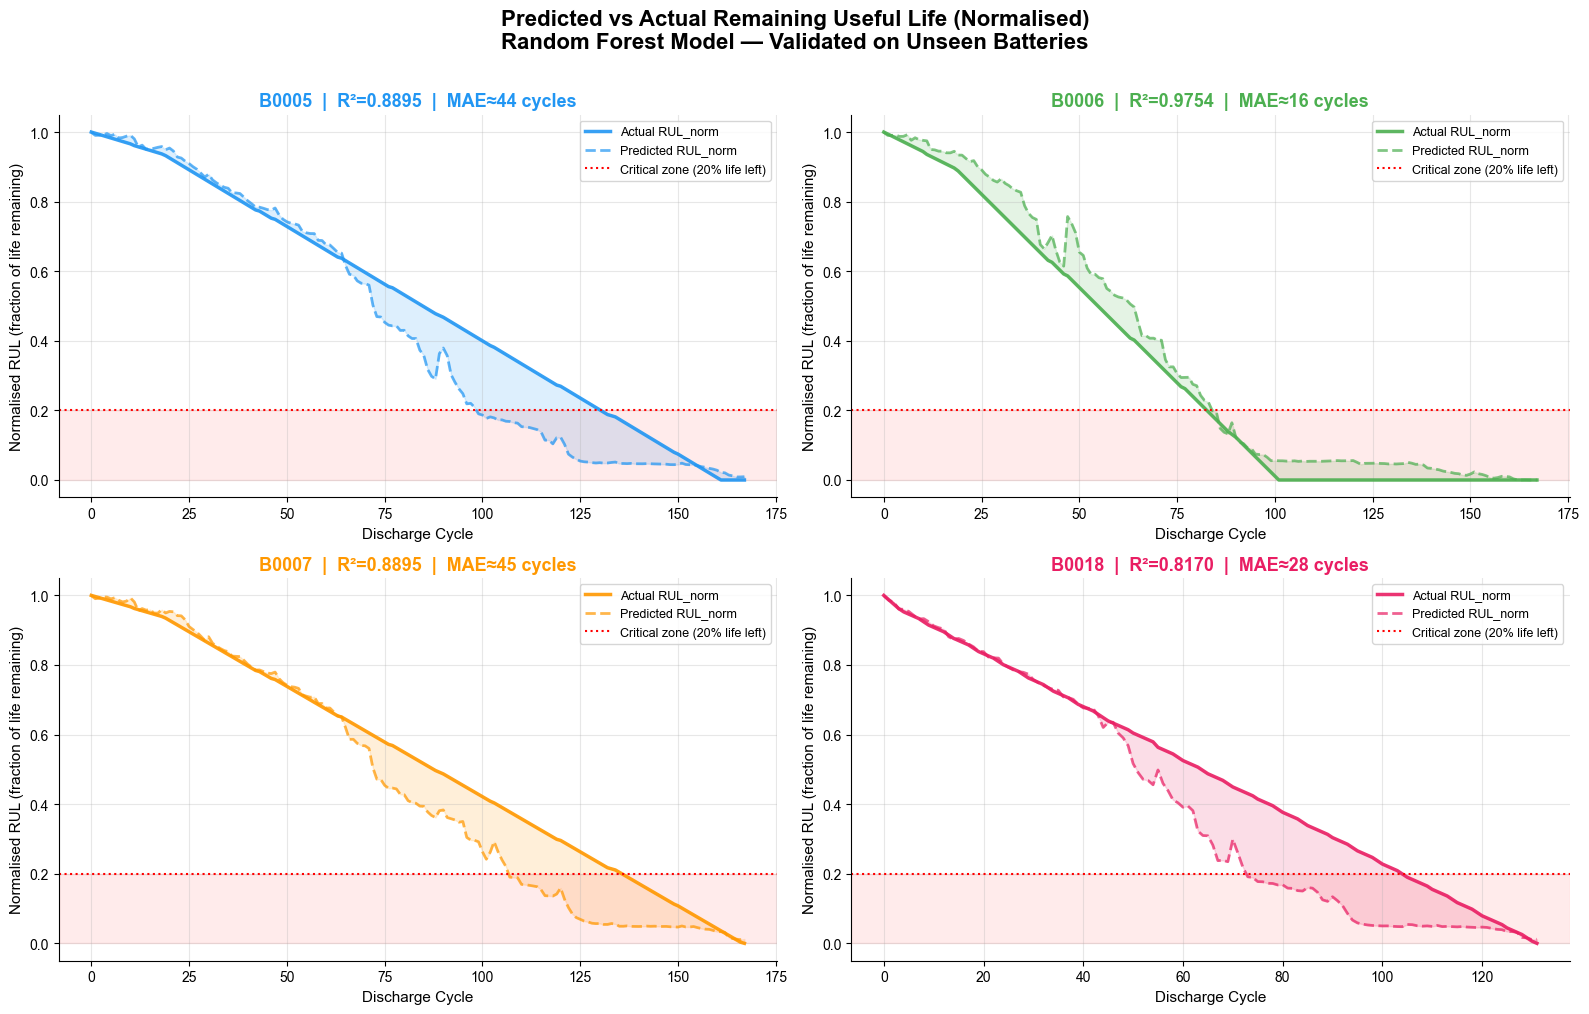

Figure 2 saved: ../figures/04_rul_predicted_vs_actual.png


In [3]:
# ── Cell 3: Figure 2 — Predicted vs Actual RUL_norm ───────────────────────────
#
# RUL_norm starts at 1.0 (brand new) and falls to 0.0 (end of life).
# This curve shows whether your model correctly anticipates the countdown
# to end-of-life — does it know early on that a battery is aging fast?

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, battery_id in enumerate(core_batteries):
    ax = axes[idx]
    battery = core_data[core_data['battery_id'] == battery_id].sort_values('test_id')
    
    cycles = range(len(battery))
    color  = colors[battery_id]
    
    ax.plot(cycles, battery['RUL_norm'].values,
            color=color, linewidth=2.5, label='Actual RUL_norm', alpha=0.9)
    
    ax.plot(cycles, battery['RUL_norm_predicted'].values,
            color=color, linewidth=2, linestyle='--',
            label='Predicted RUL_norm', alpha=0.7)
    
    ax.fill_between(cycles,
                    battery['RUL_norm'].values,
                    battery['RUL_norm_predicted'].values,
                    alpha=0.15, color=color)
    
    # Warning zone — below 20% life remaining
    ax.axhspan(0, 0.20, alpha=0.08, color='red')
    ax.axhline(y=0.20, color='red', linestyle=':', 
               linewidth=1.5, label='Critical zone (20% life left)')
    
    r2  = r2_score(battery['RUL_norm'], battery['RUL_norm_predicted'])
    mae = mean_absolute_error(battery['RUL_norm'], battery['RUL_norm_predicted'])
    
    # Convert MAE back to cycles for interpretability
    max_rul = battery['max_rul'].max()
    mae_cycles = mae * max_rul
    
    ax.set_title(f'{battery_id}  |  R²={r2:.4f}  |  MAE≈{mae_cycles:.0f} cycles',
                 fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Discharge Cycle', fontsize=11)
    ax.set_ylabel('Normalised RUL (fraction of life remaining)', fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle('Predicted vs Actual Remaining Useful Life (Normalised)\n'
             'Random Forest Model — Validated on Unseen Batteries',
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('../figures/04_rul_predicted_vs_actual.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved: ../figures/04_rul_predicted_vs_actual.png")

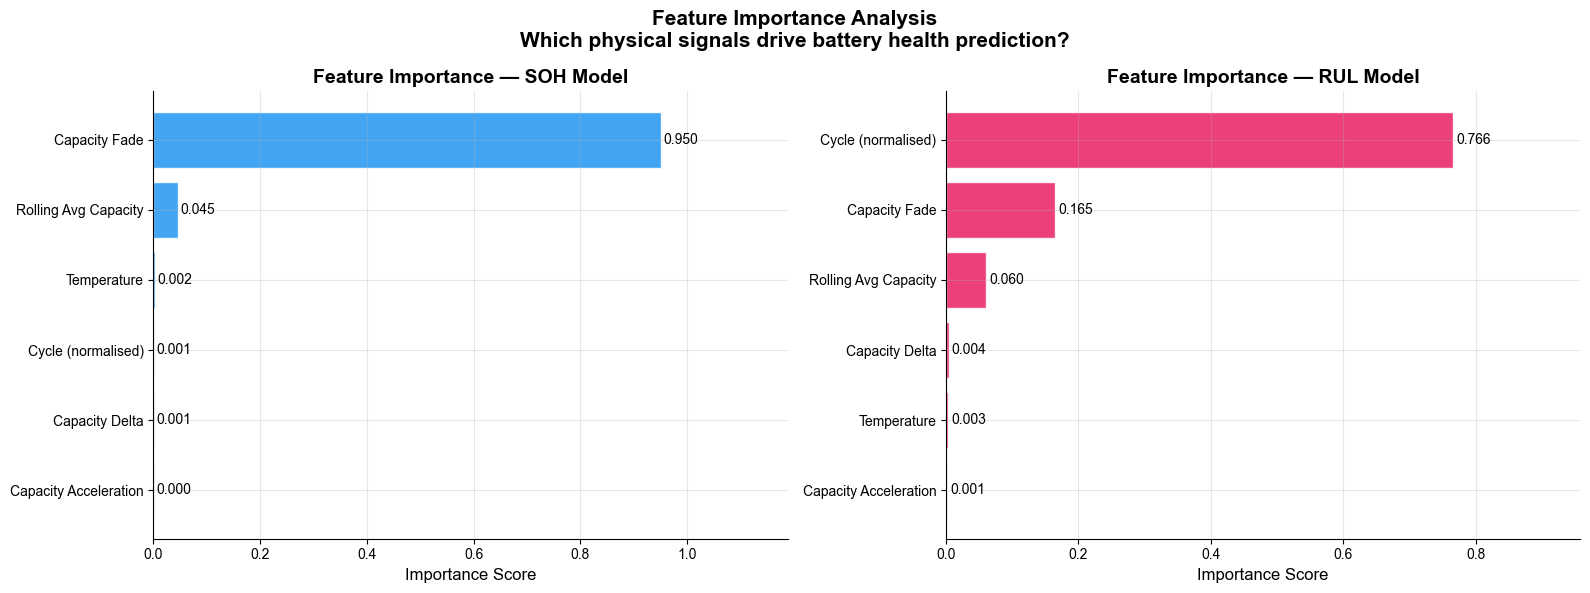

Figure 3 saved: ../figures/05_feature_importance.png


In [ ]:
# ── Cell 4: Figure 3 — Feature Importance Chart ───────────────────────────────
#
# Feature importance tells us how much each feature contributed to
# the model's decisions across all 200 trees. A higher bar means
# the model relied more heavily on that feature.

feature_names_display = [
    'Cycle (normalised)',
    'Rolling Avg Capacity',
    'Capacity Delta',
    'Capacity Acceleration', 
    'Temperature',
    'Capacity Fade',
]

# Get importance scores from both models
soh_importances = rf_soh.feature_importances_
rul_importances = rf_rul_norm.feature_importances_

# Sort by SOH importance for clean presentation
sort_idx = np.argsort(soh_importances)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SOH feature importance
ax = axes[0]
bars = ax.barh(
    [feature_names_display[i] for i in sort_idx],
    soh_importances[sort_idx],
    color='#2196F3', alpha=0.85, edgecolor='white'
)
# Add value labels on bars
for bar, val in zip(bars, soh_importances[sort_idx]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_title('Feature Importance — SOH Model', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_xlim(0, max(soh_importances) * 1.25)

# RUL feature importance
ax = axes[1]
sort_idx_rul = np.argsort(rul_importances)
bars = ax.barh(
    [feature_names_display[i] for i in sort_idx_rul],
    rul_importances[sort_idx_rul],
    color='#E91E63', alpha=0.85, edgecolor='white'
)
for bar, val in zip(bars, rul_importances[sort_idx_rul]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_title('Feature Importance — RUL Model',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_xlim(0, max(rul_importances) * 1.25)

fig.suptitle('Feature Importance Analysis\n'
             'Which physical signals drive battery health prediction?',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/05_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved: ../figures/05_feature_importance.png")

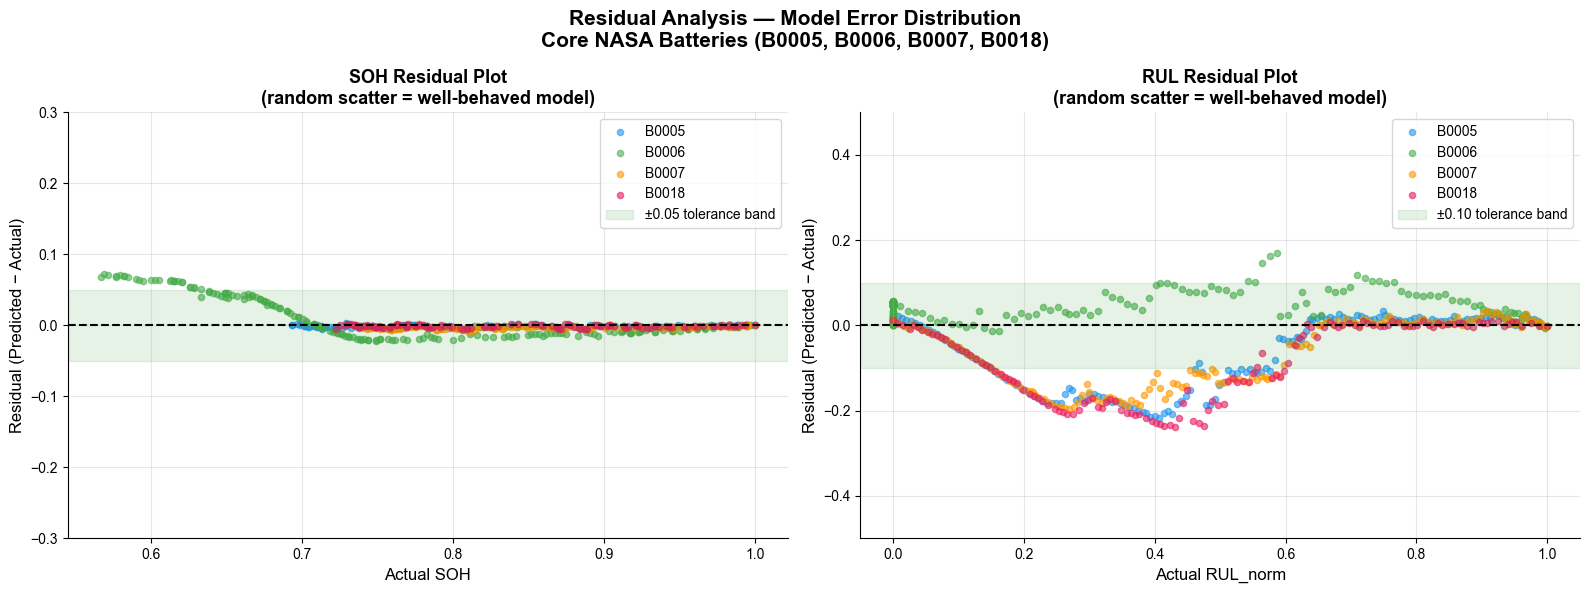

Figure 4 saved: ../figures/06_residual_analysis.png

PHASE 3 COMPLETE — ALL FIGURES GENERATED
Saved to ../figures/:
  03_soh_predicted_vs_actual.png
  04_rul_predicted_vs_actual.png
  05_feature_importance.png
  06_residual_analysis.png

These figures are ready for your GitHub README.


In [ ]:
# ── Cell 5: Figure 4 — Residual Analysis ──────────────────────────────────────
#
# A residual is the difference between predicted and actual value.
# Residual = Predicted - Actual
# A well-behaved model has residuals randomly scattered around zero
# with no systematic pattern. If you see a curve or trend in the
# residuals, it means the model has a systematic bias in some region.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SOH residuals
ax = axes[0]
for battery_id in core_batteries:
    battery = core_data[core_data['battery_id'] == battery_id]
    residuals = battery['SOH_predicted'] - battery['SOH']
    ax.scatter(battery['SOH'], residuals,
               label=battery_id, alpha=0.6, s=20,
               color=colors[battery_id])

ax.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
ax.axhspan(-0.05, 0.05, alpha=0.1, color='green', label='±0.05 tolerance band')
ax.set_xlabel('Actual SOH', fontsize=12)
ax.set_ylabel('Residual (Predicted − Actual)', fontsize=12)
ax.set_title('SOH Residual Plot\n(random scatter = well-behaved model)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-0.3, 0.3)

# RUL residuals
ax = axes[1]
for battery_id in core_batteries:
    battery = core_data[core_data['battery_id'] == battery_id]
    residuals = battery['RUL_norm_predicted'] - battery['RUL_norm']
    ax.scatter(battery['RUL_norm'], residuals,
               label=battery_id, alpha=0.6, s=20,
               color=colors[battery_id])

ax.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
ax.axhspan(-0.10, 0.10, alpha=0.1, color='green', label='±0.10 tolerance band')
ax.set_xlabel('Actual RUL_norm', fontsize=12)
ax.set_ylabel('Residual (Predicted − Actual)', fontsize=12)
ax.set_title('RUL Residual Plot\n(random scatter = well-behaved model)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-0.5, 0.5)

fig.suptitle('Residual Analysis — Model Error Distribution\n'
             'Core NASA Batteries (B0005, B0006, B0007, B0018)',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/06_residual_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved: ../figures/06_residual_analysis.png")

# ── Final Phase 3 summary ─────────────────────────────────────────────────────
print("\n" + "="*55)
print("PHASE 3 COMPLETE — ALL FIGURES GENERATED")
print("="*55)
print("Saved to ../figures/:")
print("  03_soh_predicted_vs_actual.png")
print("  04_rul_predicted_vs_actual.png")
print("  05_feature_importance.png")
print("  06_residual_analysis.png")
print("="*55)